In [22]:
import cv2 as cv
import numpy as np
import os
import utils
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

In [23]:
# Preprocessing pipeline:
# - Read image
# - Convert to grayscale
# - Resize to 64x64
# - Histogram equalization
# - Gaussian blur
# - Normalize to [0,1]
# - Flatten for ML

import cv2 as cv
import numpy as np


def preprocessing_pipeline(image_path, size=(64, 64)):
    img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Failed to read image: {image_path}")
    img = cv.resize(img, size, interpolation=cv.INTER_AREA)
    img = cv.equalizeHist(img)
    img = cv.GaussianBlur(img, (3, 3), 0)
    img = img.astype(np.float32) / 255.0
    return img.flatten()


In [24]:
data_dir = "data"  # base folder - Changed to point to the downloaded dataset
classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d)) and not d.startswith(
    '.')]  # Filter out non-directory files starting with '.'
print("Clases detectadas:", classes)

X = []
y = []

for label, cls in enumerate(classes):
    counter = 0
    folder = os.path.join(data_dir, cls)
    print(f"Processing class: {folder}")
    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        try:
            X.append(preprocessing_pipeline(path))
            y.append(int(label))
            counter += 1
        except Exception as e:  # Catch specific exception for better debugging
            print(f"Skipping file: {path} - Error: {e}")
    print(f"Processed {counter} images in class {cls}")

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

train_data = cv.ml.TrainData.create(X_train.astype(np.float32), cv.ml.ROW_SAMPLE, y_train.astype(np.float32))

Clases detectadas: ['0', '1']
Processing class: data/0
Processed 572 images in class 0
Processing class: data/1
Processed 386 images in class 1


In [25]:
best_acc = -1.0
best_cfg = None
best_matrix = None

param_grid = {
    'learning_rates': [0.01, 0.05, 0.1, 0.5, 0.7],
    'iterations': [500, 1000],
    'regularizations': [cv.ml.LOGISTIC_REGRESSION_REG_L2, cv.ml.LOGISTIC_REGRESSION_REG_L1],
    'train_methods': [cv.ml.LOGISTIC_REGRESSION_BATCH],
    'mini_batch_sizes': [1, 16, 32, 64],
}

for lr in param_grid['learning_rates']:
    for iters in param_grid['iterations']:
        for reg in param_grid['regularizations']:
            for tm in param_grid['train_methods']:
                for mbs in param_grid['mini_batch_sizes']:
                    print(
                        f"Testing params -> lr: {lr}, iters: {iters}, reg: {reg}, train_method: {tm}, mini_batch: {mbs}")
                    model1 = cv.ml.LogisticRegression.create()
                    model1.setLearningRate(lr)
                    model1.setIterations(iters)
                    model1.setRegularization(reg)
                    model1.setTrainMethod(tm)
                    model1.setMiniBatchSize(mbs)
                    model1.train(train_data)
                    _, predictions = model1.predict(X_test.astype(np.float32))
                    acc = accuracy_score(y_test, predictions)
                    if acc > best_acc:
                        best_acc = acc
                        best_cfg = (lr, iters, reg, tm, mbs)
                        best_matrix = confusion_matrix(y_test, predictions)

print(f"Best Accuracy: {best_acc * 100:.2f}% with params (lr, iters, reg, tm, mbs): {best_cfg}")
print("Confussion matrix:\n", best_matrix)


Testing params -> lr: 0.01, iters: 500, reg: 1, train_method: 0, mini_batch: 1
Testing params -> lr: 0.01, iters: 500, reg: 1, train_method: 0, mini_batch: 16
Testing params -> lr: 0.01, iters: 500, reg: 1, train_method: 0, mini_batch: 32


KeyboardInterrupt: 

In [26]:
finalModel = cv.ml.LogisticRegression.create()
finalModel.setLearningRate(0.05)
finalModel.setIterations(1000)
finalModel.setRegularization(cv.ml.LOGISTIC_REGRESSION_REG_L2)
finalModel.setTrainMethod(cv.ml.LOGISTIC_REGRESSION_BATCH)
finalModel.setMiniBatchSize(1)
finalModel.train(train_data)

True

In [27]:
_, predictions = finalModel.predict(X_test.astype(np.float32))
acc = accuracy_score(y_test, predictions)
matrix = confusion_matrix(y_test, predictions)
print(f"Accuracy: {acc * 100:.2f}%")
print("Confussion matrix:\n", matrix)

Accuracy: 76.04%
Confussion matrix:
 [[171   2]
 [ 67  48]]


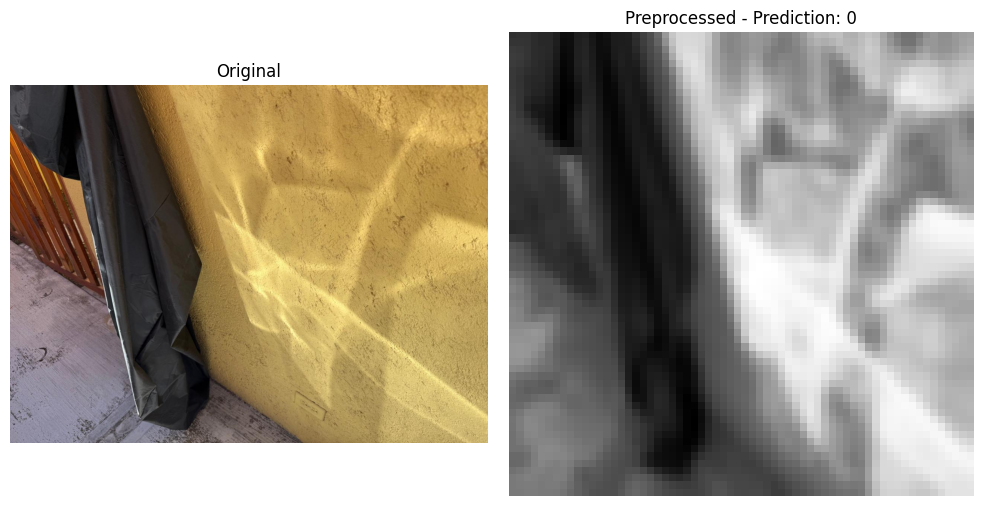

In [35]:
import matplotlib.pyplot as plt

orig_path = "testing_images/testing2.jpeg"
original_img = cv.imread(orig_path)
original_img_rgb = cv.cvtColor(original_img, cv.COLOR_BGR2RGB)

pre_img = preprocessing_pipeline(orig_path)
pre_img_float = pre_img.astype(np.float32).reshape(1, -1)
_, testPrediction = finalModel.predict(pre_img_float)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(original_img_rgb)
axs[0].set_title("Original")
axs[0].axis('off')

axs[1].imshow(pre_img.reshape(64,64), cmap='gray')
axs[1].set_title(f"Preprocessed - Prediction: {int(testPrediction.ravel()[0])}")
axs[1].axis('off')

plt.tight_layout()
plt.show()
